## Step 1: Import the Python Libraries



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load the Dataset


In [ ]:
data_url = "https://raw.githubusercontent.com/avikumart/Road-Traffic-Severity-Classification-Project/main/RTA%20Dataset.csv"
df = pd.read_csv(data_url)
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


## Step 3: Explore the Dataset



In [ ]:
print("Number of rows (accidents):", df.shape[0])
print("Number of columns (features):", df.shape[1])

Number of rows (accidents): 12316
Number of columns (features): 32


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [ ]:
df.columns

Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='object')

In [ ]:
df['Accident_severity'].value_counts()

,count
Accident_severity,
Slight Injury,10415
Serious Injury,1743
Fatal injury,158


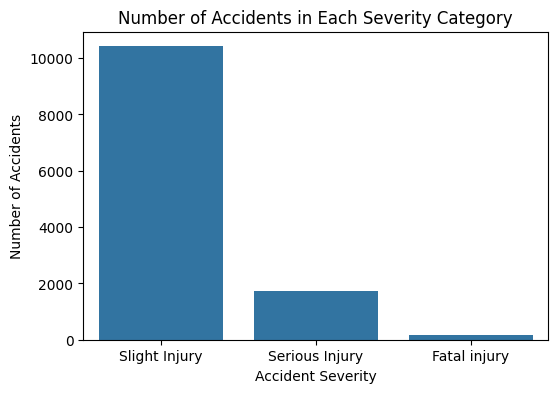

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Accident_severity', data=df, order=df['Accident_severity'].value_counts().index)
plt.title("Number of Accidents in Each Severity Category")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
plt.show()

### 🔎 Observation



In [ ]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values)

Defect_of_vehicle          4427
Service_year_of_vehicle    3928
Work_of_casuality          3198
Fitness_of_casuality       2635
Type_of_vehicle             950
Types_of_Junction           887
Driving_experience          829
Educational_level           741
Vehicle_driver_relation     579
Owner_of_vehicle            482
Lanes_or_Medians            385
Vehicle_movement            308
Area_accident_occured       239
Road_surface_type           172
Type_of_collision           155
Road_allignment             142
dtype: int64


## Step 4: Clean the Dataset


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumerical columns:", numerical_cols)

Categorical columns: ['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']

Numerical columns: ['Number_of_vehicles_involved', 'Number_of_casualties']


In [ ]:
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

print("Total missing values remaining:", df.isnull().sum().sum())

Total missing values remaining: 0


## Step 5: Feature Engineering



In [ ]:
df['Time'].head()

,Time
0,17:02:00
1,17:02:00
2,17:02:00
3,1:06:00
4,1:06:00


In [ ]:
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour
df = df.drop(columns=['Time'])
df[['Hour']].head()

,Hour
0,17
1,17
2,17
3,1
4,1


### Simplifying the problem for a clearer model



In [ ]:
feature_cols = [
    'Day_of_week',
    'Age_band_of_driver',
    'Sex_of_driver',
    'Educational_level',
    'Driving_experience',
    'Type_of_vehicle',
    'Area_accident_occured',
    'Lanes_or_Medians',
    'Road_allignment',
    'Types_of_Junction',
    'Road_surface_type',
    'Road_surface_conditions',
    'Light_conditions',
    'Weather_conditions',
    'Type_of_collision',
    'Number_of_vehicles_involved',
    'Number_of_casualties',
    'Vehicle_movement',
    'Cause_of_accident',
    'Hour'
]

target_col = 'Accident_severity'

df_model = df[feature_cols + [target_col]].copy()

df_model.head()

,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Driving_experience,Type_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,...,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Cause_of_accident,Hour,Accident_severity
0,Monday,18-30,Male,Above high school,1-2yr,Automobile,Residential areas,Unknown,Tangent road with flat terrain,No junction,...,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,Moving Backward,17,Slight Injury
1,Monday,31-50,Male,Junior high school,Above 10yr,Public (> 45 seats),Office areas,Undivided Two way,Tangent road with flat terrain,No junction,...,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,Overtaking,17,Slight Injury
2,Monday,18-30,Male,Junior high school,1-2yr,Lorry (41?100Q),Recreational areas,other,Unknown,No junction,...,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Changing lane to the left,17,Serious Injury
3,Sunday,18-30,Male,Junior high school,5-10yr,Public (> 45 seats),Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,...,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Changing lane to the right,1,Slight Injury
4,Sunday,18-30,Male,Junior high school,2-5yr,Unknown,Industrial areas,other,Tangent road with flat terrain,Y Shape,...,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Overtaking,1,Slight Injury


## Step 6: Encode Categorical Columns (Convert Text into Numbers)


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoders = {}

categorical_features = df_model.select_dtypes(include='object').columns.tolist()

categorical_features.remove(target_col)

print("Categorical feature columns to encode:", categorical_features)

Categorical feature columns to encode: ['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Driving_experience', 'Type_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Cause_of_accident']


In [ ]:
for col in categorical_features:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

df_model.head()

,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Driving_experience,Type_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,...,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Cause_of_accident,Hour,Accident_severity
0,1,0,1,0,0,0,9,5,5,1,...,0,3,2,3,2,2,2,9,17,Slight Injury
1,1,1,1,4,3,11,6,4,5,1,...,0,3,2,8,2,2,2,16,17,Slight Injury
2,1,0,1,4,0,5,1,6,9,1,...,0,3,2,2,2,2,2,0,17,Serious Injury
3,3,0,1,4,2,11,6,6,6,7,...,0,0,2,8,2,2,2,1,1,Slight Injury
4,3,0,1,4,1,17,4,6,5,7,...,0,0,2,8,2,2,2,16,1,Slight Injury


In [ ]:
target_encoder = LabelEncoder()
df_model[target_col] = target_encoder.fit_transform(df_model[target_col])

for i, class_name in enumerate(target_encoder.classes_):
    print(f"{i}  →  {class_name}")

0  →  Fatal injury
1  →  Serious Injury
2  →  Slight Injury


## Step 7: Split Data into Features (X) and Target (y)



In [ ]:
X = df_model[feature_cols]
y = df_model[target_col]

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

Shape of X (features): (12316, 20)
Shape of y (target): (12316,)


## Step 8: Split Data into Training Set and Testing Set



In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0], "rows")
print("Testing set size:", X_test.shape[0], "rows")

Training set size: 9852 rows
Testing set size: 2464 rows


## Step 9: Train Machine Learning Models





In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=10, random_state=42)
}

print("Models created:", list(models.keys()))

Models created: ['Logistic Regression', 'Decision Tree', 'Random Forest']


In [ ]:
trained_models = {}

for name, model in models.items():
    print(f"Training {name} ...")
    model.fit(X_train, y_train)
    trained_models[name] = model

print("\nAll models trained successfully!")

Training Logistic Regression ...
Training Decision Tree ...
Training Random Forest ...

All models trained successfully!


## Step 10: Evaluate the Models



In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy_scores = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_scores[name] = acc

    print("="*60)
    print(f"MODEL: {name}")
    print("="*60)
    print(f"Accuracy: {acc:.2%}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

MODEL: Logistic Regression
Accuracy: 49.39%

Classification Report:
                precision    recall  f1-score   support

  Fatal injury       0.02      0.29      0.03        31
Serious Injury       0.17      0.31      0.22       349
 Slight Injury       0.87      0.53      0.66      2084

      accuracy                           0.49      2464
     macro avg       0.35      0.38      0.30      2464
  weighted avg       0.76      0.49      0.59      2464

MODEL: Decision Tree
Accuracy: 57.75%

Classification Report:
                precision    recall  f1-score   support

  Fatal injury       0.05      0.52      0.09        31
Serious Injury       0.23      0.50      0.31       349
 Slight Injury       0.89      0.59      0.71      2084

      accuracy                           0.58      2464
     macro avg       0.39      0.53      0.37      2464
  weighted avg       0.79      0.58      0.65      2464

MODEL: Random Forest
Accuracy: 81.29%

Classification Report:
                pr

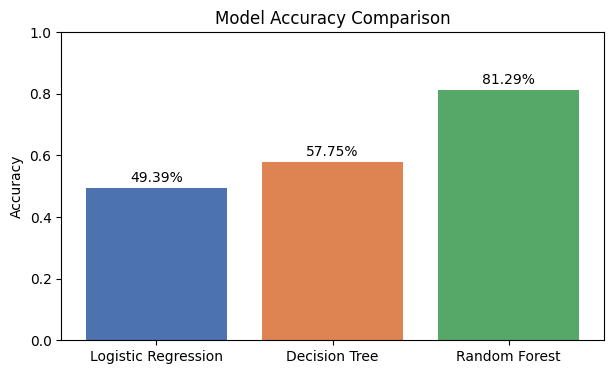

In [ ]:
plt.figure(figsize=(7,4))
plt.bar(accuracy_scores.keys(), accuracy_scores.values(), color=['#4C72B0','#DD8452','#55A868'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, (name, acc) in enumerate(accuracy_scores.items()):
    plt.text(i, acc + 0.02, f"{acc:.2%}", ha='center')
plt.show()

### Let's look closer at the best model using a Confusion Matrix



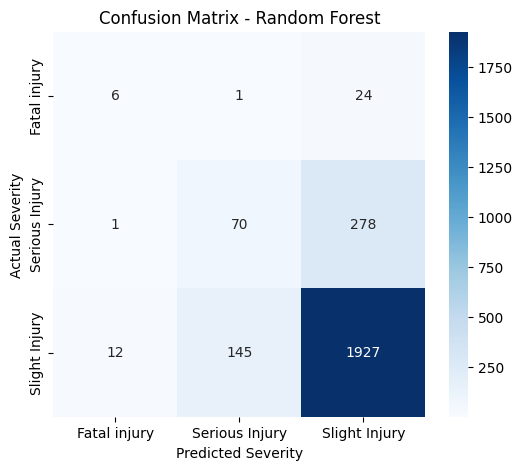

In [ ]:
best_model_name = "Random Forest"
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Severity")
plt.ylabel("Actual Severity")
plt.show()

## Step 11: Which Factors Cause Serious Accidents? (Feature Importance)


In [ ]:
importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df

,Feature,Importance
16,Number_of_casualties,0.154720
19,Hour,0.111558
15,Number_of_vehicles_involved,0.075129
0,Day_of_week,0.072438
18,Cause_of_accident,0.063730
5,Type_of_vehicle,0.056994
1,Age_band_of_driver,0.056720
9,Types_of_Junction,0.055594
4,Driving_experience,0.047047
6,Area_accident_occured,0.046894


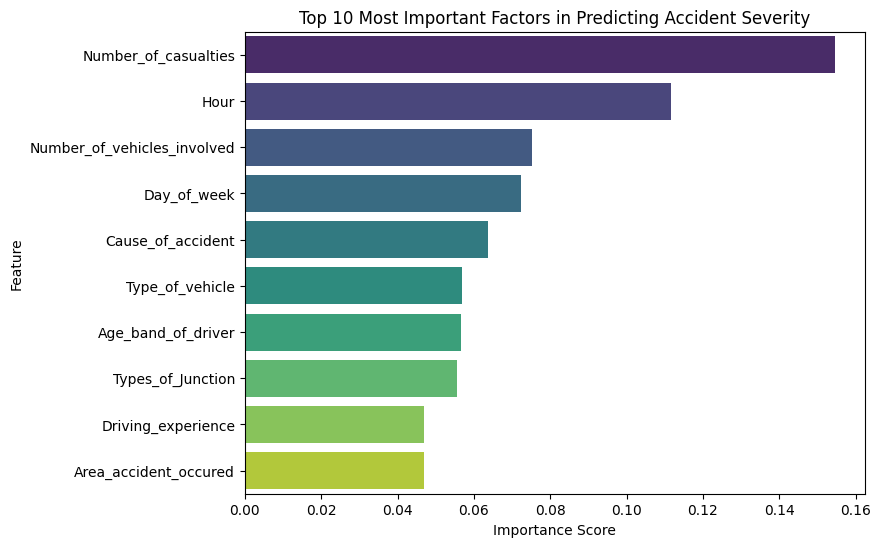

In [ ]:
plt.figure(figsize=(8,6))
top_10 = feature_importance_df.head(10)
sns.barplot(x='Importance', y='Feature', data=top_10, palette='viridis')
plt.title("Top 10 Most Important Factors in Predicting Accident Severity")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

## Step 12: Making a Prediction on a New (Sample) Accident



In [ ]:
sample = X_test.iloc[[0]]
actual_answer = y_test.iloc[0]

predicted_answer = best_model.predict(sample)[0]

actual_label = target_encoder.inverse_transform([actual_answer])[0]
predicted_label = target_encoder.inverse_transform([predicted_answer])[0]

print("Actual Severity:    ", actual_label)
print("Predicted Severity: ", predicted_label)

Actual Severity:     Slight Injury
Predicted Severity:  Serious Injury
